In [1]:
# Let's add the root directory to our system search path to allow imports from sibling directories.
import os, sys
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import random
import torch
import numpy as np
import cv2
from sklearn.decomposition import PCA
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pathlib import Path

# Import your modules
from src.dino import ConvNeXtV2
from src.dataset import NormalizeTransform, SonarDataset

WEIGHTS_DIR = Path("../weights/")
EPOCH_COUNT = len(list(WEIGHTS_DIR.iterdir())) - 1

DEVICE = torch.device("cuda")  # ConvNeXtV2 doesn't support CPU

N_TILES = 5
TRAIN_SET = 100  # For PCA visualization
DATASET = SonarDataset(data_dir="../data/processed/", tile_size=768)
N = len(DATASET)

/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:97: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:163: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/spconv/pytorch/functional.py:243: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Pl

In [13]:
def load_backbone(weights_path) -> ConvNeXtV2:
    """
    Loads the ConvNeXtTiny backbone from the training checkpoint.
    """
    checkpoint = torch.load(weights_path, map_location='cpu', weights_only=False)

    # Extract student weights
    if 'student' in checkpoint:
        state_dict = checkpoint['student']
    else:
        # Fallback if the user passes a raw state dict
        state_dict = checkpoint

    # The training code wrapped the model in MultiCropWrapper, so keys have 'backbone.' prefix.
    # We need to strip this prefix to load into ConvNeXtTiny directly.
    backbone_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith('backbone.'):
            new_key = k.replace('backbone.', '')
            backbone_state_dict[new_key] = v

    if not backbone_state_dict:
        raise ValueError("No 'backbone.' keys found in the checkpoint. Check the weight file structure.")

    model = ConvNeXtV2(in_chans=1)
    model.load_state_dict(backbone_state_dict)
    model.to(DEVICE)
    model.eval()

    return model


def run_inference(model, tile):
    transform = NormalizeTransform()

    patch_dim = tile.shape[-1]
    with torch.no_grad():
        input_tensor = transform(tile).unsqueeze(0).to(DEVICE)

        # Forward pass returns class embedding and patch embeddings
        cls, patch = model(input_tensor)

        # Upsample in the feature space (done in cpu so can be done while training)
        downsample_dim = int(np.sqrt(patch.shape[1]))
        upsampled_patch = patch.reshape((patch.shape[0], downsample_dim, downsample_dim, patch.shape[2]))
        upsampled_patch = upsampled_patch.permute(0, 3, 1, 2)
        upsampled_patch = F.interpolate(upsampled_patch.cpu(), size=(patch_dim, patch_dim), mode='nearest')
        upsampled_patch = upsampled_patch.permute(0, 2, 3, 1)

        return cls.squeeze().cpu().numpy(),\
            patch.squeeze().cpu().numpy(),\
            upsampled_patch.squeeze().cpu().numpy()


def get_visualizations(model: ConvNeXtV2, indices):
    patches = [DATASET[i * N // TRAIN_SET][0] for i in range(TRAIN_SET)]
    processed = [run_inference(model, p) for p in patches]

    stacked_patches = np.concatenate([p[1] for p in processed], axis=0) # (total patches, Dim)

    pca = PCA(n_components=3, whiten=True)
    pca.fit(stacked_patches)

    visuals = []
    for i in indices:
        tile = DATASET[i][0]
        _, _, upsampled_patch = run_inference(model, tile)

        img = tile.squeeze().cpu().numpy()
        gray_vis = (255 * np.clip(img, 0, 1)).astype(np.uint8)
        gray_vis = cv2.cvtColor(gray_vis, cv2.COLOR_GRAY2BGR)

        patch_dim = tile.shape[-1]

        # Transform ALL features of this image to pixel space
        pca_patch = upsampled_patch.reshape(-1, upsampled_patch.shape[-1])
        pca_patch = pca.transform(pca_patch) # (H*W, 3)
        pca_patch = pca_patch.reshape(patch_dim, patch_dim, 3)

        # Sigmoid & Scaling for more vibrant colors
        pca_patch = 1.0 / (1.0 + np.exp(-2 * pca_patch))
        pca_patch = (255 * pca_patch).astype(np.uint8)

        visuals.append((gray_vis, pca_patch))

    return visuals


def get_random_indices():
    if N < N_TILES:
        return list(range(N))
    return random.sample(range(N), N_TILES)


def show_images(images):
    _, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i, image in enumerate(images):
        axes[i].imshow(image[0])
        axes[i].set_title(image[1])
        axes[i].axis('off')
    plt.show()

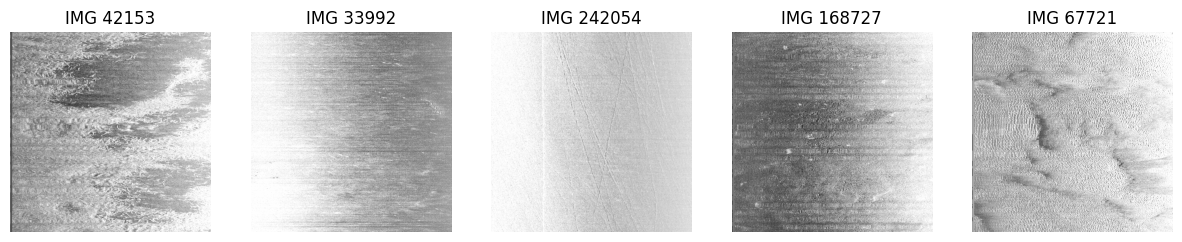

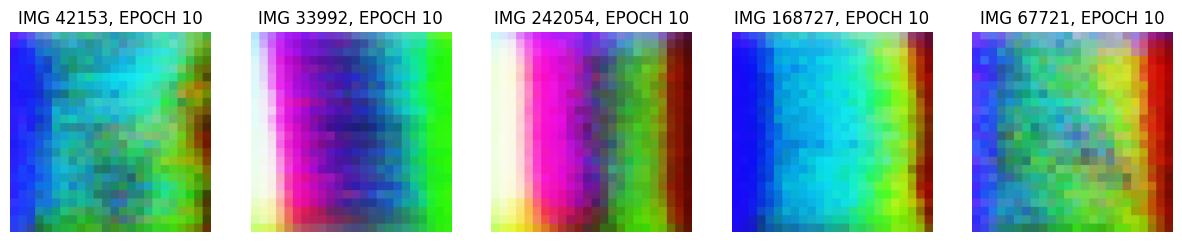

In [14]:
# Visualize features of latest epoch

indices = get_random_indices()
show_images([(
    cv2.cvtColor((255 * DATASET[i][0].squeeze().cpu().numpy()).astype(np.uint8), cv2.COLOR_GRAY2RGB), f"IMG {i}")
    for i in indices
])

model = load_backbone(WEIGHTS_DIR / "checkpoint_latest.pth")
visuals = get_visualizations(model, indices)

show_images([
    (v[1], f"IMG {indices[i]}, EPOCH {EPOCH_COUNT - 1}")
    for i, v in enumerate(visuals)
])

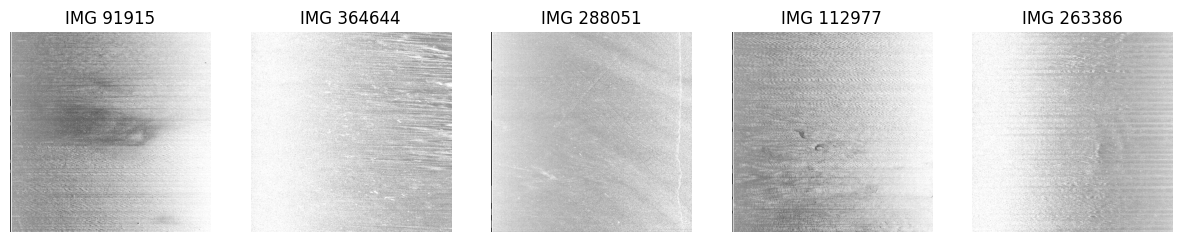

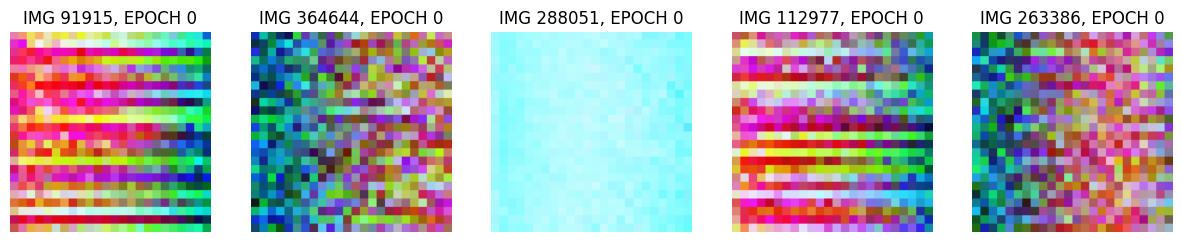

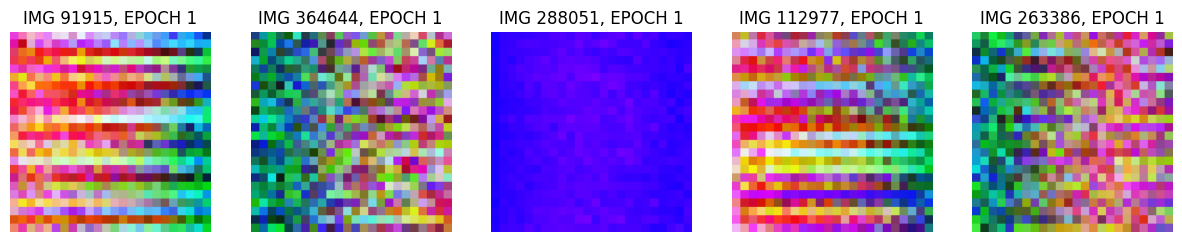

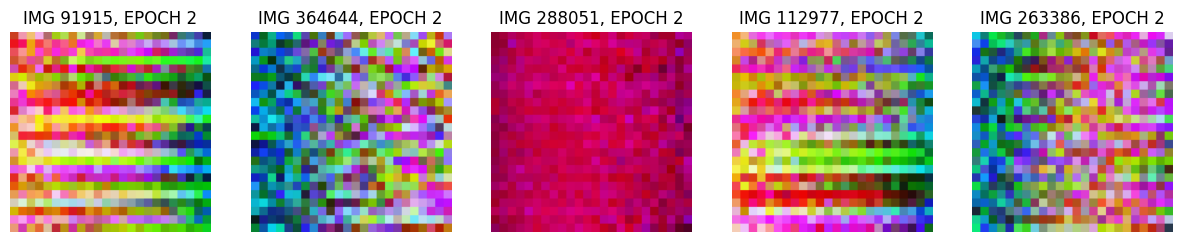

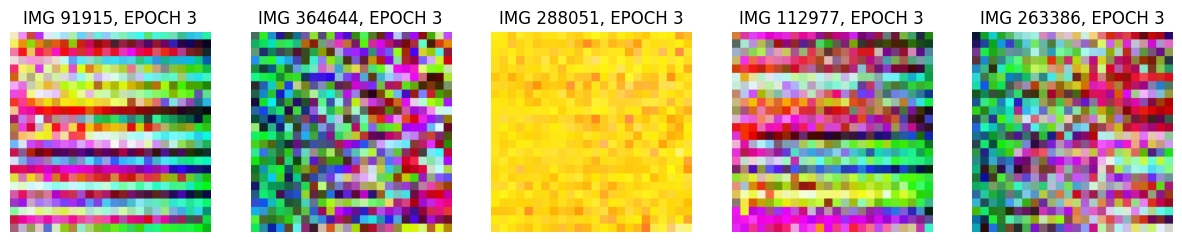

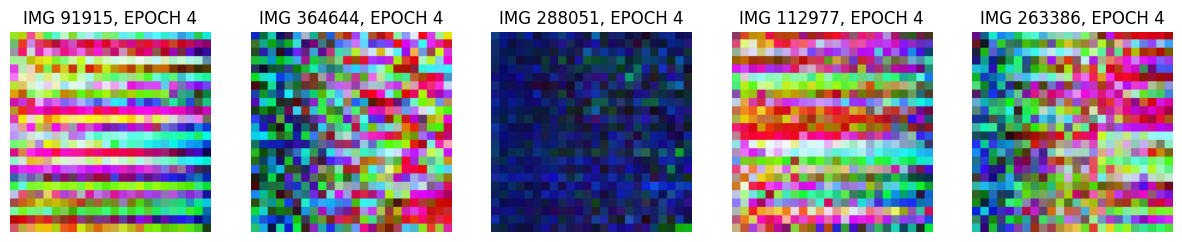

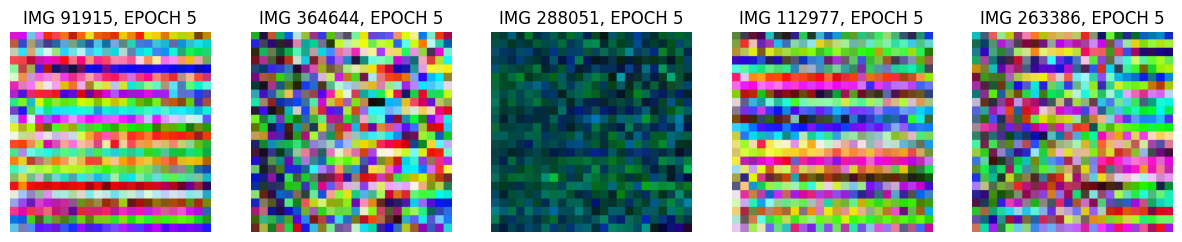

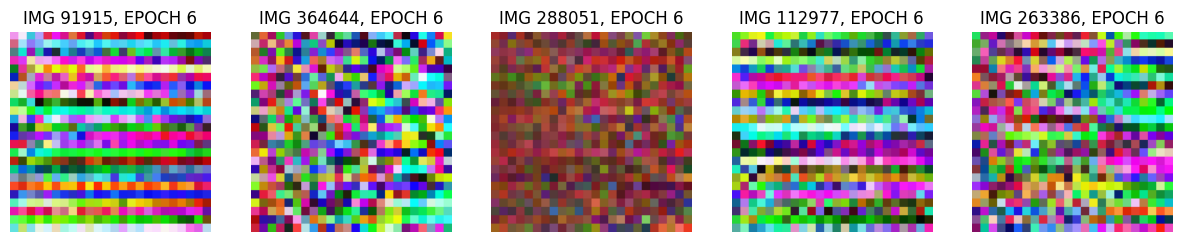

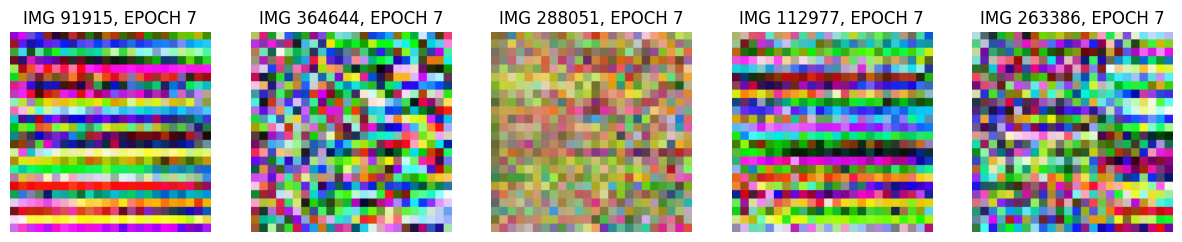

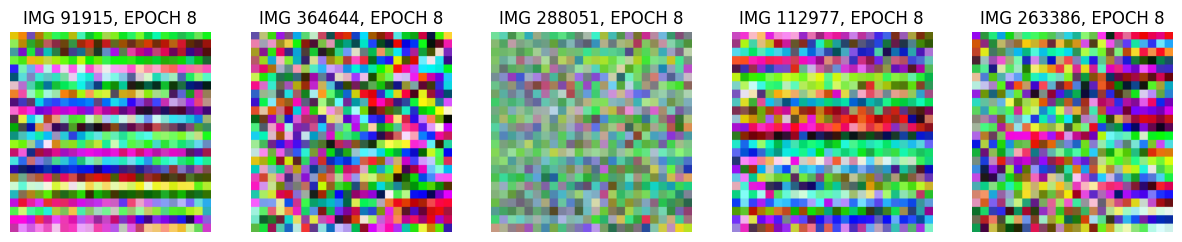

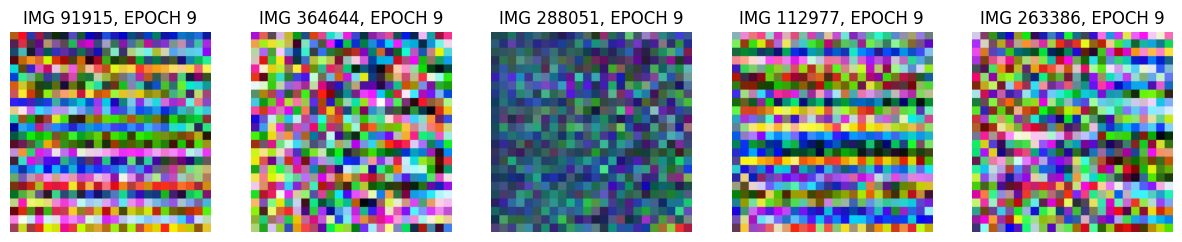

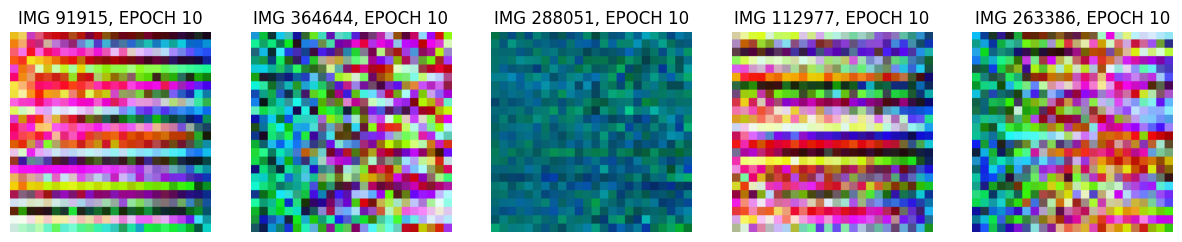

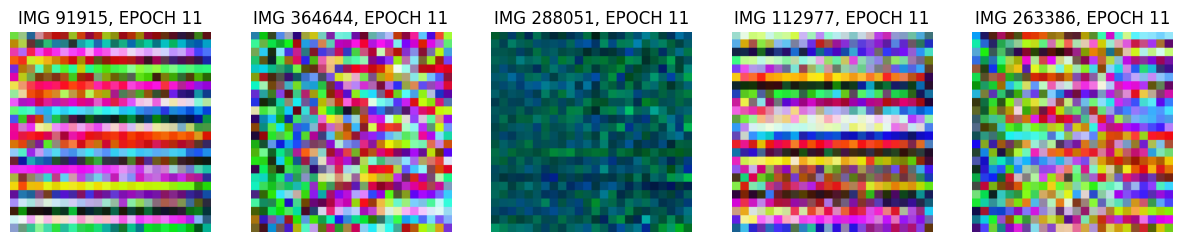

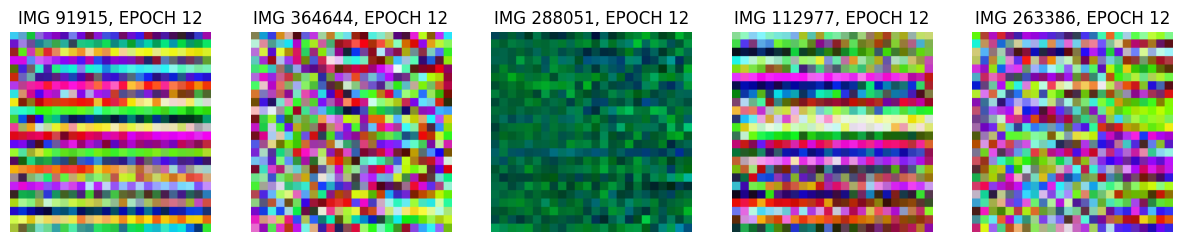

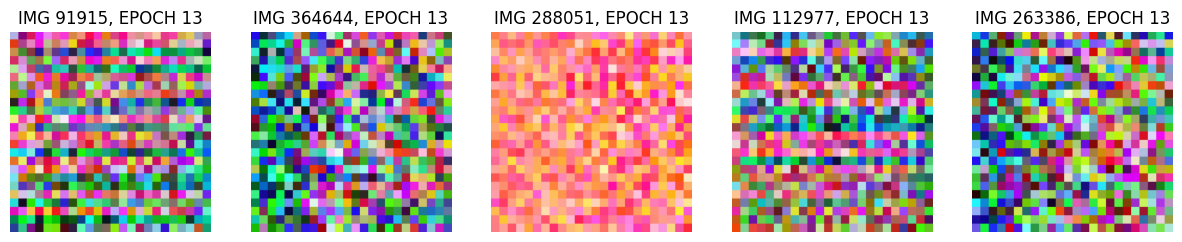

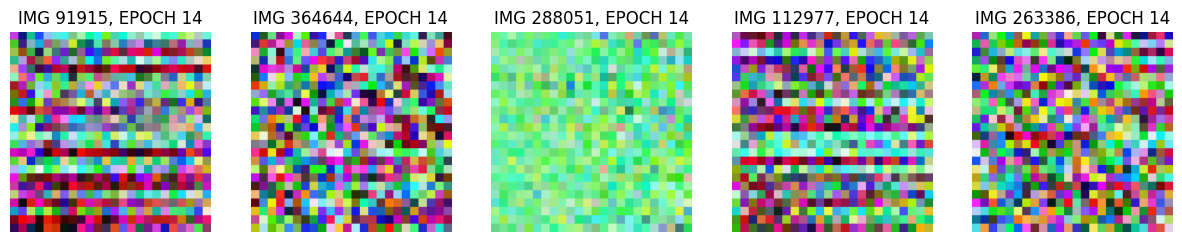

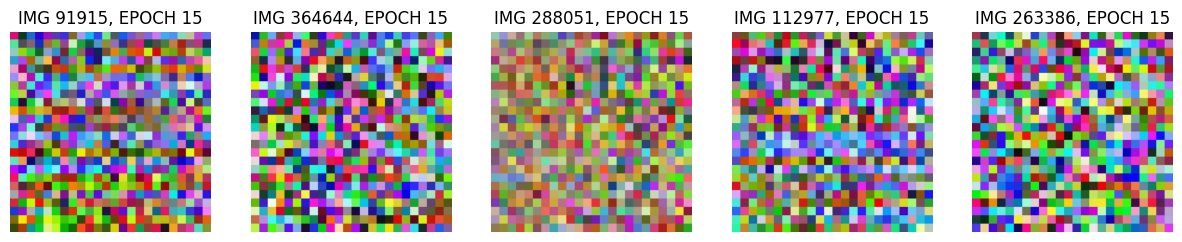

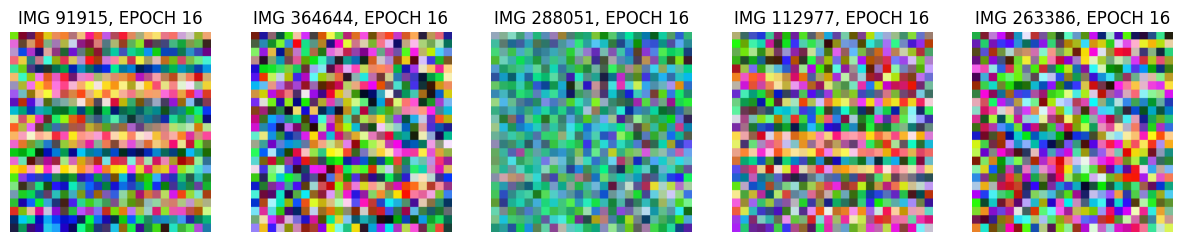

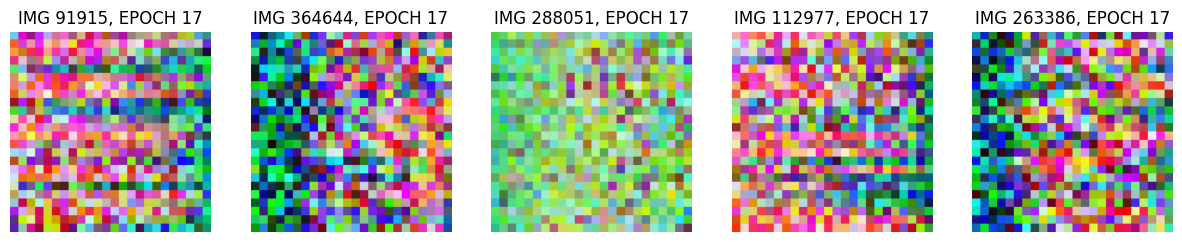

In [6]:
# Visualize features of every epoch

indices = get_random_indices()
show_images([(
    cv2.cvtColor((255 * DATASET[i][0].squeeze().cpu().numpy()).astype(np.uint8), cv2.COLOR_GRAY2RGB), f"IMG {i}")
    for i in indices
])

for epoch in range(EPOCH_COUNT):
    model = load_backbone(WEIGHTS_DIR / f"checkpoint_{epoch}.pth")
    visuals = get_visualizations(model, indices)

    show_images([
        (v[1], f"IMG {indices[i]}, EPOCH {epoch}")
        for i, v in enumerate(visuals)
    ])